# PyTorch Workflow
Let's explore an example PyTorch end-to-end workflow.

Resources:
* Ground-truth notebook – https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* Book version – https://www.learnpytorch.io/01_pytorch_workflow/
* Discussions – https://github.com/mrdbourke/pytorch-deep-learning/discussions
*
Our Workflow:
1. Data (loading and preparing)
2. Build a model
3. Fitting the model to data (training)
4. Making predictions and evaluating a model (inference)
5. Saving and loading a model
6. Putting all of it together

In [10]:
import torch
from torch import nn
import matplotlib.pyplot as plt
# Check pytorch version
print(torch.__version__)

2.12.0+cu130


## Data Preparing and Loading
Data can be anything... in Machine Learning.
You can have:
* Images of any king
* Text
* Excel Spreadsheet or Tabular Data
* Audio like podcasts, songs
* Videos
* DNA

Machine Learning is a game of two parts:
1. Getting data into a numerical representation.
2. Building a model to learn patterns in that numerical representation.

To showcase this, let's create some _known_ data using the Linear Regression formula.
We'll use a linear regression formula to make a straight line with _known_ **parameters**.


In [3]:
# Create _known_ parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10],

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting Data into Training and Test sets
This is one of the most **important** concepts in Machine Learning.
We **split** the data into:
1. Training set:
Our model learns from this dataset. _Think of it as the study materials._ Around **60–80%** of the data. This is always used.
2. Validation set:
We tune our model using this data set. _Think of it as a Practice exam._ Around **10–20%** of the data. This is often used, but not always.
3. Test set:
We evaluate our model using this data set. _Think of it as the final exam._ Around **10–20%** of the data. This is always used.

Let's split our above data into training and testing sets.

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize the data? This is where the data-explorer's moto comes in...

**"Visualize, visualize, visualize!"**
### Plotting the Data

In [6]:
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data, and predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot the training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
    # Plot the testing data
    plt.scatter(test_data, test_labels, c='g', s=4, label="Testing Data")
    # Plot the predictions if any
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")
    # Show the legends
    plt.legend(prop={'size': 14})

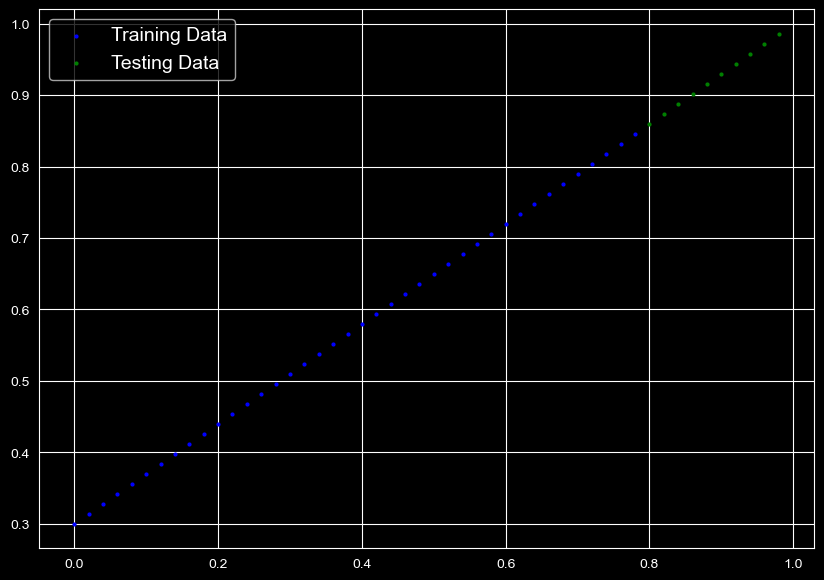

In [7]:
plot_prediction()

## Building the model
Let's build our very first PyTorch model. Because we're going to be building classes all along, refer to the following resource: https://realpython.com/python3-object-oriented-programming/

What our model does:
1. Start with random values (weight and bias).
2. Look at training data and adjust the random values to better represent (or get closer to) the ideal values of the data (weight and bias values we used to create the data).

How does it do so? Mainly, through these two algorithms:
1. Gradient descent
2. Backpropagation

In [11]:
# Create a Linear Regression model
class LinearRegressionModel(nn.Module): #<- Almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                             dtype=torch.float))
        # Forward method to define the computation in the model (forward pass)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.weights * x + self.bias